In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.io
import re
import itertools
import pickle

import os
from os.path import join
import contextlib
from copy import deepcopy
import imp 
import time 
import sys

# add path
sys.path.append('/media/jorvhar/Data1/OneDrive_Mint/Documenten/Maastricht/processing_scripts/predadapt_fmri/ses2_modelstims')

# load local functions
import stim_io
import stim_io_plotting
import vtc

import Adaptation.longtrace_adaptation as longtrace_adaptation
import IdealObserver.idealobserver as idealobserver

## Load in (non-specific) data for modelling

In [95]:
pp = 5  # for illustation purposes
input_dir = '/media/jorvhar/Data8T/MRIData/timing data/data'

tr = 1.8
volumes = 235
nr_runs=12

# settings
par = scipy.io.loadmat(join(input_dir, '/media/jorvhar/Data8T/MRIData/timing data/grid_parameters.mat'))
mat = scipy.io.loadmat(join(input_dir, '{}/{}_settings_tonotopy.mat'.format(pp, pp)))
all_freqs = mat['cfg']['freq_array'][0][0][0,:]

# must match the tonotopy settings
tunsteps       = par['tunsteps'][0][0]
freqstep       = par['freqstep'][0][0]
subsample      = par['subsample'][0] - 1
mustep         = par['mustep'][0]
muarray_bins   = par['muarray'][0]
muarray        = par['muarray_bins'][0]

# check if matlab and python values are consistent
if not np.all(np.abs(np.concatenate((muarray_bins, muarray)) - np.concatenate((all_freqs, all_freqs[subsample]))) <  1e-10):
    print('Warning; matlab and python muarray values inconsistent')

# tuning sizes
fwhm           = par['fwhm'][0]    #HIERGEBLEVEN \/
octgrid        = par['octgrid'][0]
sigmagrid      = par['real_sigma'][0]

# set range of tunings and sharpnesses
pref_range  = muarray                # match t
sharp_range_fwhm = fwhm              # sharp range in octaves
sharp_range = sigmagrid

# store into dict and save dict to mat
variables = {
            'tunsteps': tunsteps,
            'freqstep': freqstep,
            'subsample': subsample,
            'mustep': mustep,
            'muarray_bins': muarray_bins,
            'muarray': muarray,
            'fwhm': fwhm,
            'octgrid': octgrid,
            'sigmagrid': sigmagrid,
            'pref_range': pref_range,
            'sharp_range_fwhm': sharp_range_fwhm,
            'sharp_range': sharp_range
}

puls_df = stim_io.pulses_load(str(pp), input_dir, 10)
volumes_df = stim_io.volumes_load(puls_df, tr, volumes, nr_runs=10)

mat, stimuli = stim_io.data_load(str(pp), join(input_dir, str(pp)))
stim_df = stim_io.stims_load(puls_df, volumes_df, mat, stimuli)

## Plot normative timecourses for one block(part)

/tmp/ipykernel_2381373/699785436.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stim_df['prec_w_surprisal'] = stim_df['precision'] * stim_df['surprisal'] # add precision weighted surprisal


pRF(CF, Width) = pRF(2500.0Hz, 0.43oct)


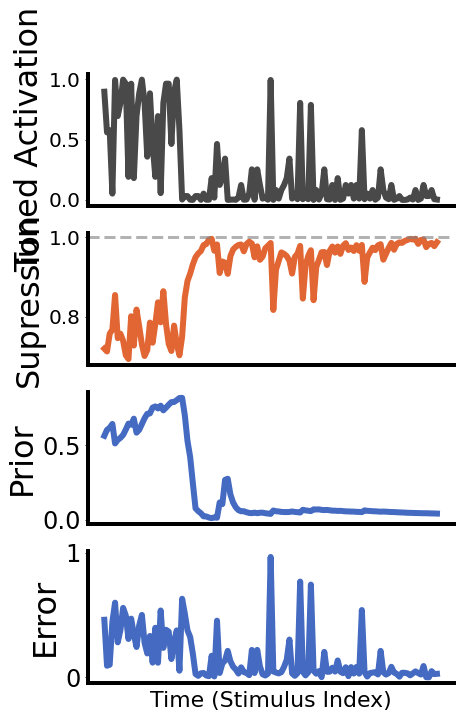

In [96]:
## ADAPTATION PLOT 2

blocknr = 1 
octvspace = True
lenback = 125#144


# reload dataframe
puls_df = stim_io.pulses_load(str(pp), input_dir, 10)
volumes_df = stim_io.volumes_load(puls_df, tr, volumes, nr_runs=10)
mat, stimuli = stim_io.data_load(str(pp), join(input_dir, str(pp)))
stim_df = stim_io.stims_load(puls_df, volumes_df, mat, stimuli)


sigma1 = 0.45
prf_mu = 11.3

# adaptation decay settings
x_decay, y_decay = longtrace_adaptation.double_exp_decay_func(0.1399, 0.85, 0.0345, 6.82, [1, 10], 1)
 
## 2b. Add trial level adaptation                    #
activations, adaptations, adapted_activations, n_back_adaptations = stim_io.run_adaptation(stim_df, 
                                                                                           pref_range, 
                                                                                           sharp_range, 
                                                                                           y_decay)
stim_df = stim_io.stims_add_adaptation(stim_df, 
                                       pref_range, 
                                       sharp_range, 
                                       activations, 
                                       1-adaptations,       # take 1-adaptation to make filling with 0s possible
                                       adapted_activations)
del activations, adaptations, adapted_activations, n_back_adaptations # cleanup vars for memory


## 2c. Add trial level expectations
stim_df = stim_io.stims_add_drex(str(pp), input_dir, stim_df)
stim_df['prec_w_surprisal'] = stim_df['precision'] * stim_df['surprisal'] # add precision weighted surprisal
# normalize
stim_df['glob_err'] = stim_io.normalize(stim_df['glob_err']) # normalize global error
stim_df['surprisal'] = stim_io.normalize(stim_df['surprisal']) # normalize surprisal to decoralzate with onoff function
stim_df['precision'] = stim_io.normalize(stim_df['precision']) # normalize surprisal to decoralzate with onoff function
stim_df['prec_w_surprisal'] = stim_io.normalize(stim_df['prec_w_surprisal'])

## 2d. Calculate error from D-Rex and raw_activation
stim_df = stim_io.stims_add_error(stim_df, pref_range, sharp_range)

# make sellection
stim_df_sel = stim_df.loc[(stim_df['block'] == blocknr) &
                          (stim_df['frequencies_oct'].notnull())]
stim_df_sel = stim_df_sel.iloc[-lenback:]

# get closest sigma to model
closestsigma = np.argmin(np.abs(sigmagrid - sigma1))
closestsigma = sigmagrid[closestsigma]

# do same for mu
closestmu = np.argmin(np.abs(pref_range - prf_mu))
closestmu = pref_range[closestmu]

# sellect collumns adapt (a)
colnames = stim_io.get_tw_collumns(stim_df_sel, 
                                   closestmu,
                                   closestsigma,
                                   pred_reg='M',surp_reg='M',prec_reg='M',precsurp_reg='M',exta_reg='M') # dont want these
raw_adapt_col = [name for name in colnames if 'raw_adapt' in name]
raw_activ_col = [name for name in colnames if 'raw_acti' in name]
adaptacti_col = [name for name in colnames if 'adapt_activ' in name]

# sellect collumns expect (b)
colnames = stim_io.get_tw_collumns(stim_df_sel, 
                                   closestmu,
                                   closestsigma,
                                   acti_reg='M',
                                   adpt_reg='M',
                                   acadpt_reg='M',
                                   exta_reg='M') # dont want these
pred_prob_col = [name for name in colnames if 'pred_prob' in name]
surp_col = [name for name in colnames if 'surprisal' == name]
prec_col = [name for name in colnames if 'precision' in name]
pw_surpr = [name for name in colnames if 'prec_w_surprisal' in name]
error_col = [name for name in colnames if 'error' in name]

import matplotlib.pyplot as plt
import numpy as np

# Assuming stim_df_sel and other required data are already defined as per your code

# Set plotting with adjusted height ratios
fig, ax = plt.subplots(4, 1, 
                       sharex=True, 
                       figsize=(6.5, 10),  # Adjust the figsize to maintain proportionality
                       gridspec_kw={'height_ratios': [1, 1, 1,1]})  # Top plot 2x larger

# Plot data
ax[0].plot(stim_df_sel[raw_activ_col].to_numpy(), color='#494949', lw=6)
ax[1].plot(1 - stim_df_sel[raw_adapt_col].to_numpy(), color='#E26634', lw=6)
ax[2].plot(stim_df_sel[pred_prob_col].to_numpy(), color='#446BC1', lw=6)
ax[3].plot(stim_df_sel[error_col].to_numpy(), color='#446BC1', lw=6)

# Adjust tick labels
ax[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Remove x tick labels for top plot
ax[1].tick_params(axis='x', labelsize=20)  # Set x tick label size for bottom plot
ax[1].set_xticks([])

# Remove y-ticks and labels for the top plot
# ax[0].tick_params(axis='y', which='both', left=True, right=False, labelleft=False)
ax[0].tick_params(axis='y', labelsize=20) 
yticks = yticks = np.linspace(0, 1, 3)
ax[0].set_yticks(yticks)
ax[1].tick_params(axis='y', labelsize=20) 

# Set y-label for bottom plot
ax[0].set_ylabel('Tuned Activation', fontsize=32)
ax[1].set_ylabel('Supression', fontsize=32)
ax[2].set_ylabel('Prior', fontsize=32)
ax[3].set_ylabel('Error', fontsize=32)

# Set x-label for buttom plat
ax[3].set_xlabel('Time (Stimulus Index)', fontsize=22)

ax[1].axhline(y=1, color='grey', alpha=0.6, lw=3, linestyle='--')

# Match style of ax[2] to ax[0] and ax[1]
ax[2].tick_params(axis='x', labelsize=24)
ax[2].tick_params(axis='y', labelsize=24)
# Match style of ax[3] to ax[0] and ax[1]
ax[3].tick_params(axis='x', labelsize=24)
ax[3].tick_params(axis='y', labelsize=24)

# set background color 
ax[0].patch.set_alpha(0.0)
ax[1].patch.set_alpha(0.0)
ax[2].patch.set_alpha(0.0)
ax[3].patch.set_alpha(0.0)

# Adjust layout for a tighter fit
fig.tight_layout()
fig.subplots_adjust(top=0.90)  # Leave space at the top for the title


# Remove upper and right borders
for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

for spine in ['left', 'bottom']:  # Thicken lower and left borders
    ax[0].spines[spine].set_linewidth(4)
    ax[1].spines[spine].set_linewidth(4)
    ax[2].spines[spine].set_linewidth(4)
    ax[3].spines[spine].set_linewidth(4)
    
# Add title
# fig.suptitle(f'pRF(CF, Width) = pRF({round(2**closestmu, -2)}Hz, {closestsigma:.2f}oct)', fontsize=20, y=0.95)
print(f'pRF(CF, Width) = pRF({round(2**closestmu, -2)}Hz, {closestsigma:.2f}oct)')

# # Save the plot as SVG and PDF
fig.savefig('v_2500.svg', format='svg', bbox_inches='tight')
fig.savefig('v_2500.pdf', format='pdf', bbox_inches='tight')


# Show the plot
plt.show()



## Additonally plot Stimulus train for same blockpart - with 1 or 2 tuned voxels visualized

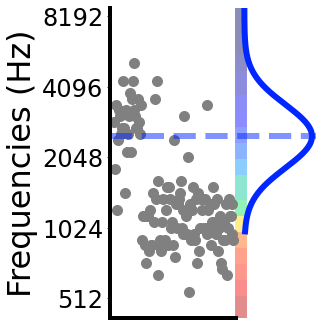

In [148]:
## BASIC PLOTTING OF GAUSSIANS

from scipy.stats import norm
import matplotlib.colors as mcolors

def lighten_color(hex_color, blend_factor=0.55):
    """Lighten a hex color by blending it with white."""
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    return mcolors.to_hex(rgb * (1 - blend_factor) + white * blend_factor)

# set example voxels
sigma1 = 0.85
prf_mu1 = 10.1
sigma2 = 0.45
prf_mu2 = 11.3

color1 = '#2C7DFF' #- #5b8e7d
color2 = '#FF3030'#- #bc4b51


blocknr = 1 
octvspace = True

# where block is 1
idxblock = np.where(mat['timingz'][1] == blocknr) 

# get frequency presentation data for block
frequencies = stimuli['pres_freq'][blocknr-1, :]

# other values
tps = np.sum(mat['timingz'][3, idxblock] == 1)  # get trials per section

# get timings back from mat file, subtract begin time
timings = mat['timingz'][4, idxblock] - np.min(mat['timingz'][4, idxblock]) 

matidx = np.where(mat['segmentz'][1] == blocknr)

centa = 2**np.repeat(mat['segmentz'][7][matidx], tps)   # cent freq a
centb = 2**np.repeat(mat['segmentz'][8][matidx], tps)   # cent freq b
proba = np.repeat(mat['segmentz'][5][matidx], tps)      # prob a
probb = np.repeat(mat['segmentz'][6][matidx], tps)      # prob b

# ACTUAL PLOTTING
fig, ax = plt.subplots(1, 
                       1, 
                       sharex=True,
                       figsize=(5.5/1.2, 5.625/1.2))





# octave transform if wanted
if octvspace: 
    frequencies = np.log2(frequencies)
    centa = np.log2(centa)
    centb = np.log2(centb)

freq_sel = frequencies[-lenback:]
tim_sel = timings[0][-lenback:]
    
# Top plot
scatter = ax.scatter(tim_sel, freq_sel, color='grey', s=100)  # dots remain log-scaled
ax.tick_params(axis='x', which='major', labelsize=20)           # set tick sizes x 
ax.tick_params(axis='y', which='major', labelsize=20)           # and y

# Adjust y-axis to show Hz values (2**log_freq)
yticks = ax.get_yticks()  # Get the current y-axis ticks (log scale)
ytick_labels = [f"{2**ytick:.0f}" for ytick in yticks]  # Convert ticks to Hz
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=24)  # Update tick labels
ax.set_ylabel('Frequencies (Hz)', fontsize=32)

ax.set_xticks([])

# Ensure timings and probb are 1-dimensional
timings = np.squeeze(tim_sel)
probb = 1-np.squeeze(probb)

# Calculate tighter y-limits
y_min, y_max = np.min(frequencies), np.max(frequencies)
y_padding = 0.1 * (y_max - y_min)  # Add a small padding
y_min, y_max = y_min - y_padding, y_max + y_padding

# Calculate tighter x-limits
x_min, x_max = np.min(timings)-1, np.max(timings)
x_padding = 0.02 * (x_max - x_min)  # Add a small padding
x_min, x_max = x_min, x_max + x_padding

# Apply limits
ax.set_ylim(y_min, y_max)
ax.set_xlim(x_min, x_max)

# Customizing borders
for spine in ['top', 'right']:  # Remove upper and right borders
    ax.spines[spine].set_visible(False)

for spine in ['left', 'bottom']:  # Thicken lower and left borders
    ax.spines[spine].set_linewidth(4)



# ax[0].axhline(y=centa[0], color='darkred', linestyle='-', alpha=0.5, ls='--', lw=4)
# ax[0].axhline(y=centb[0], color='darkred', linestyle='-', alpha=0.5, ls='--', lw=4)


from scipy.stats import norm


## SET CORRECT PRF COLORS
# find indexes of mus
mu1_idx = np.argmin(np.abs(pref_range - prf_mu1))
mu2_idx = np.argmin(np.abs(pref_range - prf_mu2))

# find indexes of sigmas
sig1_idx = np.argmin(np.abs(sharp_range - sigma1))
sig2_idx = np.argmin(np.abs(sharp_range - sigma2))

# calc colormaps
colormap_mu = np.linspace(10, -10, 240)
colormap_s = np.linspace(10, -10, 10)
mu1_c = round(colormap_mu[mu1_idx])
mu2_c = round(colormap_mu[mu2_idx])
sig1_c = round(colormap_mu[sig1_idx])
sig2_c = round(colormap_mu[sig2_idx])

# colormap
colormapping_prf = {
    0:  '#33ff0b',
    1:  '#99ff06',
    2:  '#ffff00',
    3:  '#FFCF00',
    4:  '#ff5f00',
    5:  '#ff2f00',
    6:  '#f70000',
    7:  '#bf0000',
    8:  '#870000',
    9:  '#780000',
    10: '#6e0000',
    -1: '#0fe361',
    -2: '#00c79b',
    -3: '#008fff',
    -4: '#0057ff',
    -5: '#0027ff',
    -6: '#0000ff',
    -7: '#0000ef',
    -8: '#0000b7',
    -9: '#000087',
    -10:'#000064'
}
colormapping_prf_biassed = {
    0:  '#FFD700',
    1:  '#FF5F00',
    2:  '#FF2F00',
    3:  '#FB1800',
    4:  '#F70000',
    5:  '#BF0000',
    6:  '#870000',
    7:  '#780000',
    8:  '#780000',
    9:  '#780000',
    10: '#6e0000',
    -1: '#0fe361',
    -2: '#00c79b',
    -3: '#008fff',
    -4: '#0057ff',
    -5: '#0027ff',
    -6: '#0000ff',
    -7: '#0000ef',
    -8: '#0000b7',
    -9: '#000087',
    -10:'#000064'
}

# set shift of gaussians
xmaxshift = 3.2 # set to 0 for orginal spacing

# ## GAUSSIAN 1
# # Generate x-values for the Gaussian
# y_gaussian = np.linspace(-3 * sigma1, 3 * sigma1, 500)  # Covers ±3σ range
# gaussian = norm.pdf(y_gaussian, loc=0, scale=sigma1)  # Generate Gaussian curve

# # Normalize the Gaussian height to fit visually beside the plot
# gaussian = gaussian / max(gaussian) * (y_max - y_min) * 4   # Scale to 10% of y-range

# # Add Gaussian A beside the top subplot
# ax.plot(gaussian + x_max - 1 + xmaxshift, y_gaussian + prf_mu1, color=colormapping_prf_biassed[mu1_c], lw=4)

## GAUSSIAN 2
# Generate x-values for the Gaussian
y_gaussian = np.linspace(-3 * sigma2, 3 * sigma1, 500)  # Covers ±3σ range
gaussian = norm.pdf(y_gaussian, loc=0, scale=sigma2)  # Generate Gaussian curve

# Normalize the Gaussian height to fit visually beside the plot
gaussian = gaussian / max(gaussian) * (y_max - y_min) * 4   # Scale to 10% of y-range

# Add Gaussian A beside the top subplot
ax.plot(gaussian + x_max - 1 + xmaxshift, y_gaussian + prf_mu2, color=colormapping_prf_biassed[mu2_c], lw=6)


# ax.axhline(prf_mu1, lw=4, alpha=0.5, ls='--', color=colormapping_prf_biassed[mu1_c])
ax.axhline(prf_mu2, lw=6, alpha=0.5, ls='--', color=colormapping_prf_biassed[mu2_c])



## rainboy plot
# Parameters for short lines
line_length = 0.5  # in x-axis units (adjust as needed)
line_x_start = x_max + 1  # align just under the Gaussian
line_x_end = line_x_start + line_length
yspace = np.linspace(np.log2(400), np.log2(8800), 40)
for yc in yspace:
    current_idx = np.argmin(np.abs(pref_range - yc))
    current_c = round(colormap_mu[current_idx])
    light_color = lighten_color(colormapping_prf_biassed[current_c], blend_factor=0.55)
    ax.plot([line_x_start, line_x_end], [yc, yc], lw=9.9, alpha=1, color=light_color,
           zorder=0)



# # Adjust the x-limits to accommodate the Gaussians
ax.set_xlim(x_min, x_max + max(gaussian) + xmaxshift)  # Extend x_max to fit the Gaussians
ax.spines['bottom'].set_bounds(x_min, x_max)

# Save the plot as SVG and PDF
# fig.savefig('abstractdistr.svg', format='svg', bbox_inches='tight')
fig.savefig('abstractdistr.pdf', format='pdf', bbox_inches='tight')


plt.tight_layout()
plt.show()



## Plot waveform for same stimuli

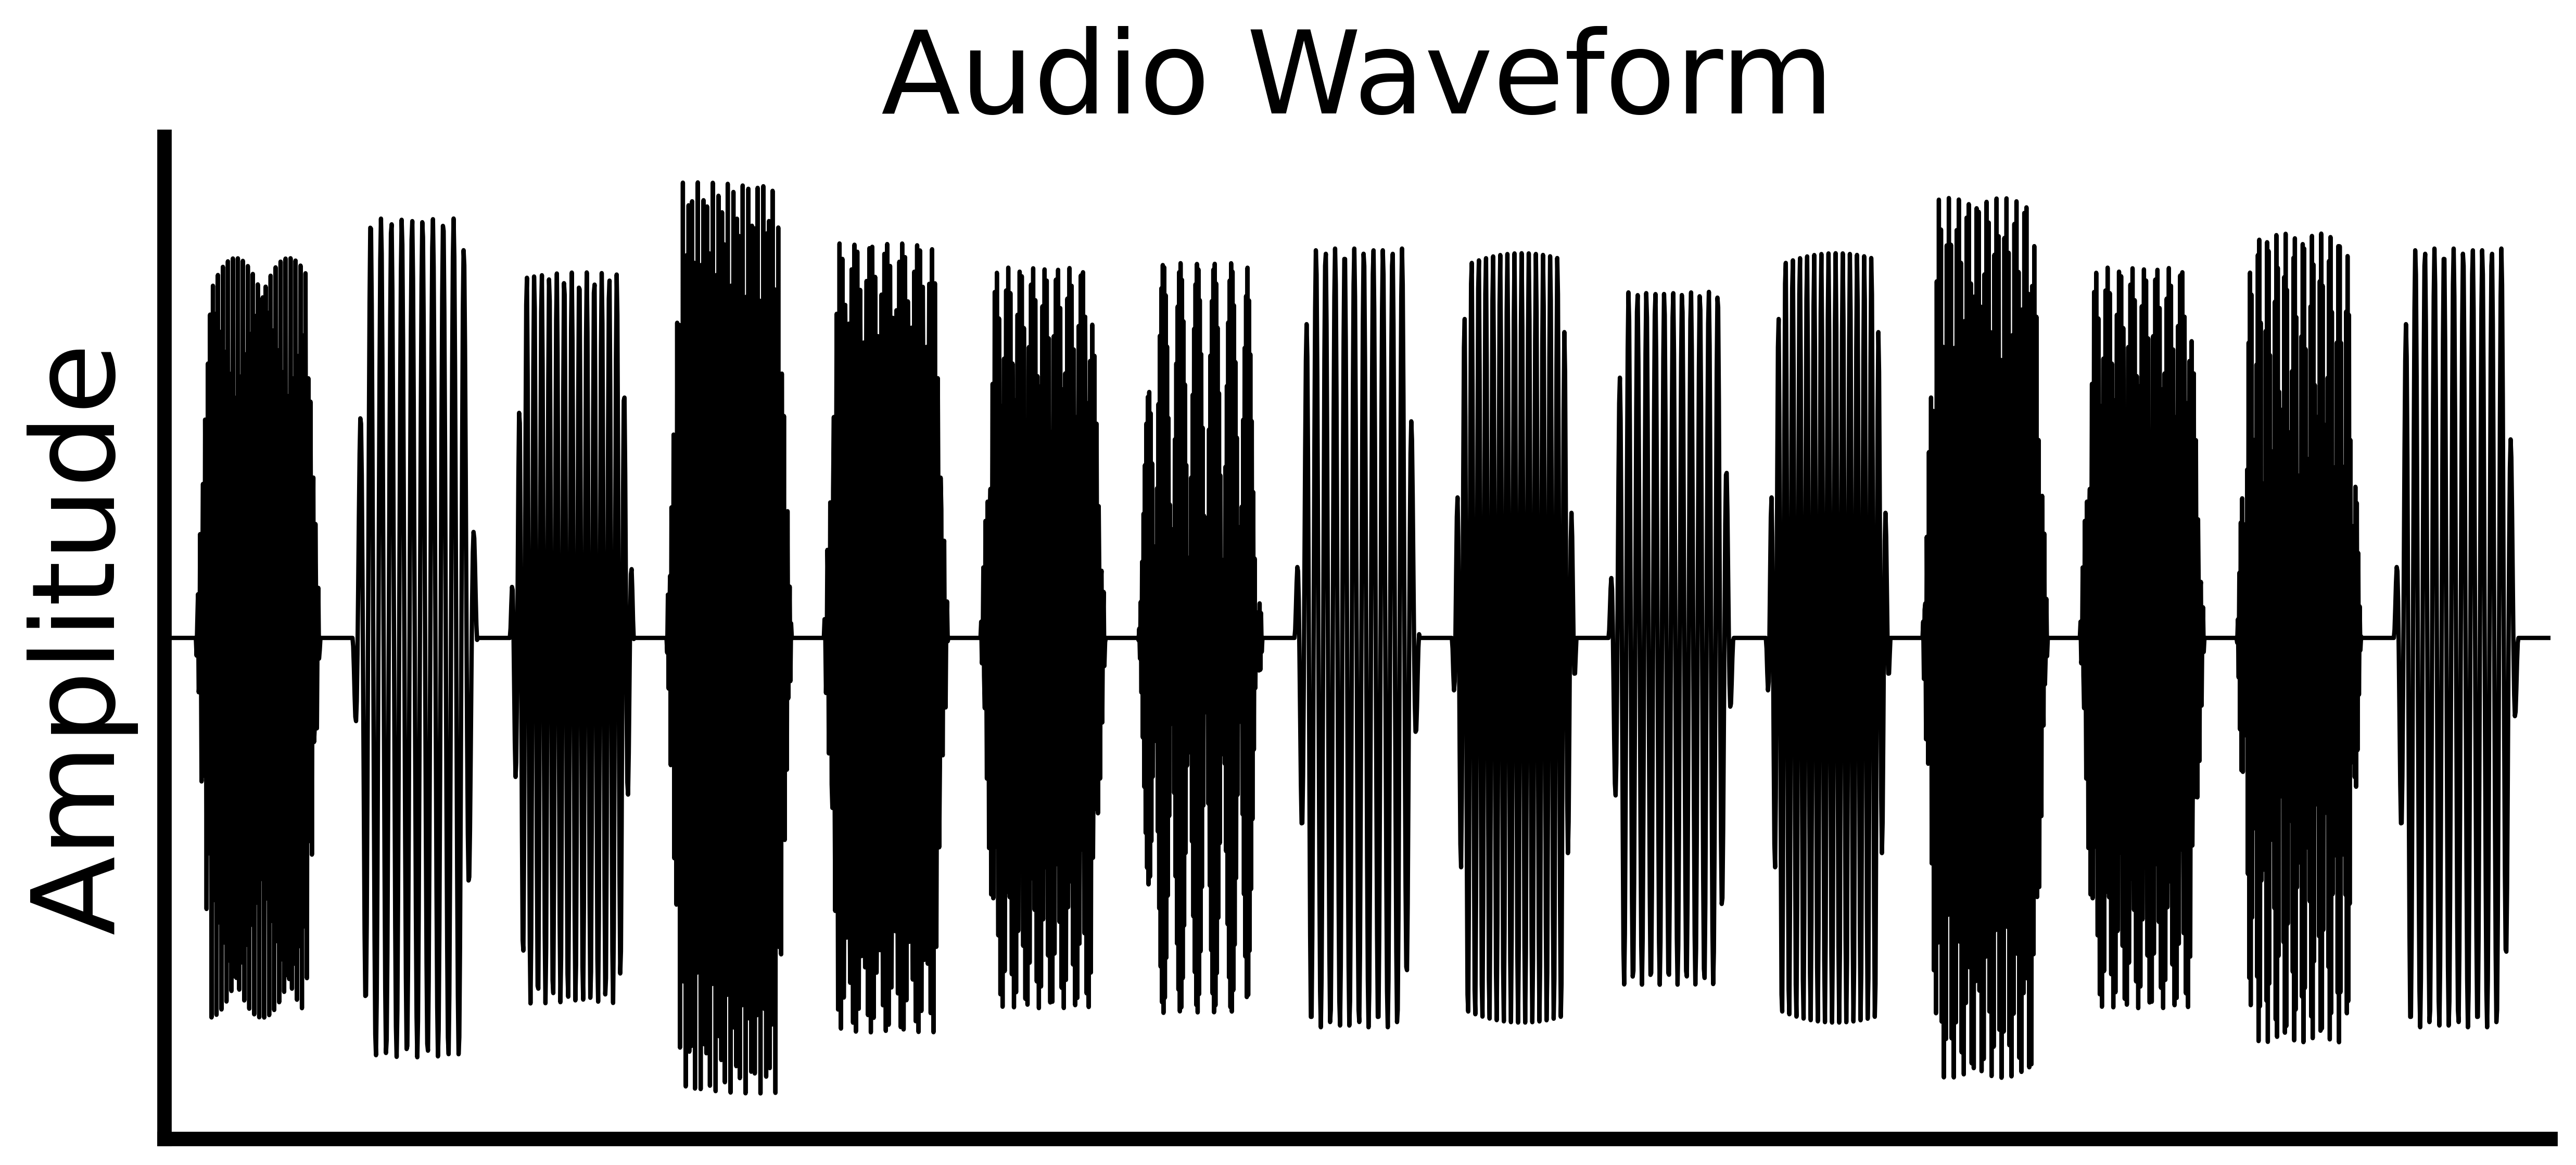

In [82]:
on_off_periods = [[(i*0.25), 0.2 ,freq_sel[i]] for i in range(len(freq_sel))]
pad = 0.05  # seconds of silence before and after the tone sequence

nr_tones = 15

# Determine start and end of the window from the first and 10th tone
first_tone_time = on_off_periods[0][0]
window_start = on_off_periods[0][0] - pad
window_end = on_off_periods[nr_tones-1][0] + on_off_periods[nr_tones-1][1] + pad

# Low sampling rate for visualization
fs_vis = 882  # 100x downsampled
duration_window = window_end - window_start
t_vis = np.linspace(window_start, window_end, int(fs_vis * duration_window), endpoint=False)
wave_vis = np.zeros_like(t_vis)

# Define ramp duration in seconds and samples
ramp_dur = 0.025  # 25 ms ramp
ramp_samples = int(ramp_dur * fs_vis)

# Approximate equal loudness function
def approx_equal_loudness_gain(freq_hz):
    log_f = np.log2(freq_hz)
    return 1.0 - 0.2 * (log_f - 25)**2  # mild quadratic dip, max at 1000 Hz

# Generate tones
for (start, duration, freq_oct) in on_off_periods:
    relative_start = start - first_tone_time
    if relative_start + duration < window_start or relative_start > window_end:
        continue

    tone_start = max(relative_start, window_start)
    tone_end = min(relative_start + duration, window_end)
    freq_hz = 2 ** freq_oct
    gain = approx_equal_loudness_gain(freq_hz)

    start_idx = int((tone_start - window_start) * fs_vis)
    end_idx = int((tone_end - window_start) * fs_vis)
    tone_len = end_idx - start_idx

    if tone_len <= 1:
        continue

    tone_t = np.linspace(0, tone_len / fs_vis, tone_len, endpoint=False)
    tone_wave = gain * np.sin(2 * np.pi * freq_hz * tone_t)

    envelope = np.ones(tone_len)
    ramp_up = np.linspace(0, 1, min(ramp_samples, tone_len // 2))
    ramp_down = np.linspace(1, 0, min(ramp_samples, tone_len // 2))
    envelope[:len(ramp_up)] = ramp_up
    envelope[-len(ramp_down):] = ramp_down

    wave_vis[start_idx:end_idx] += tone_wave * envelope

# Normalize
wave_vis /= np.max(np.abs(wave_vis))

# Plot
fig, ax = plt.subplots(figsize=(10, 4.58), dpi=500)
ax.plot(t_vis, wave_vis, color='black', linewidth=1.2)
# ax.plot(t_vis, wave_vis + 0.01, color='black', linewidth=1.3)
# ax.axhline(0, color='black', linewidth=0.5)  # Zero line
ax.set_xlim(window_start, window_end)
ax.set_ylim(-1.1, 1.1)
ax.set_ylabel('Amplitude', fontsize=32)
ax.set_yticks([])
ax.set_title('Audio Waveform', fontsize=32)
ax.set_xticklabels([])
ax.tick_params(axis='x', length=0)

# Customizing borders
for spine in ['top', 'right']:  # Remove upper and right borders
    ax.spines[spine].set_visible(False)

for spine in ['left', 'bottom']:  # Thicken lower and left borders
    ax.spines[spine].set_linewidth(4)

plt.tight_layout()
fig.savefig("visabstract2.pdf", format="pdf")
plt.show()




## plot behaviour of adapation given n-1,2,3 etc

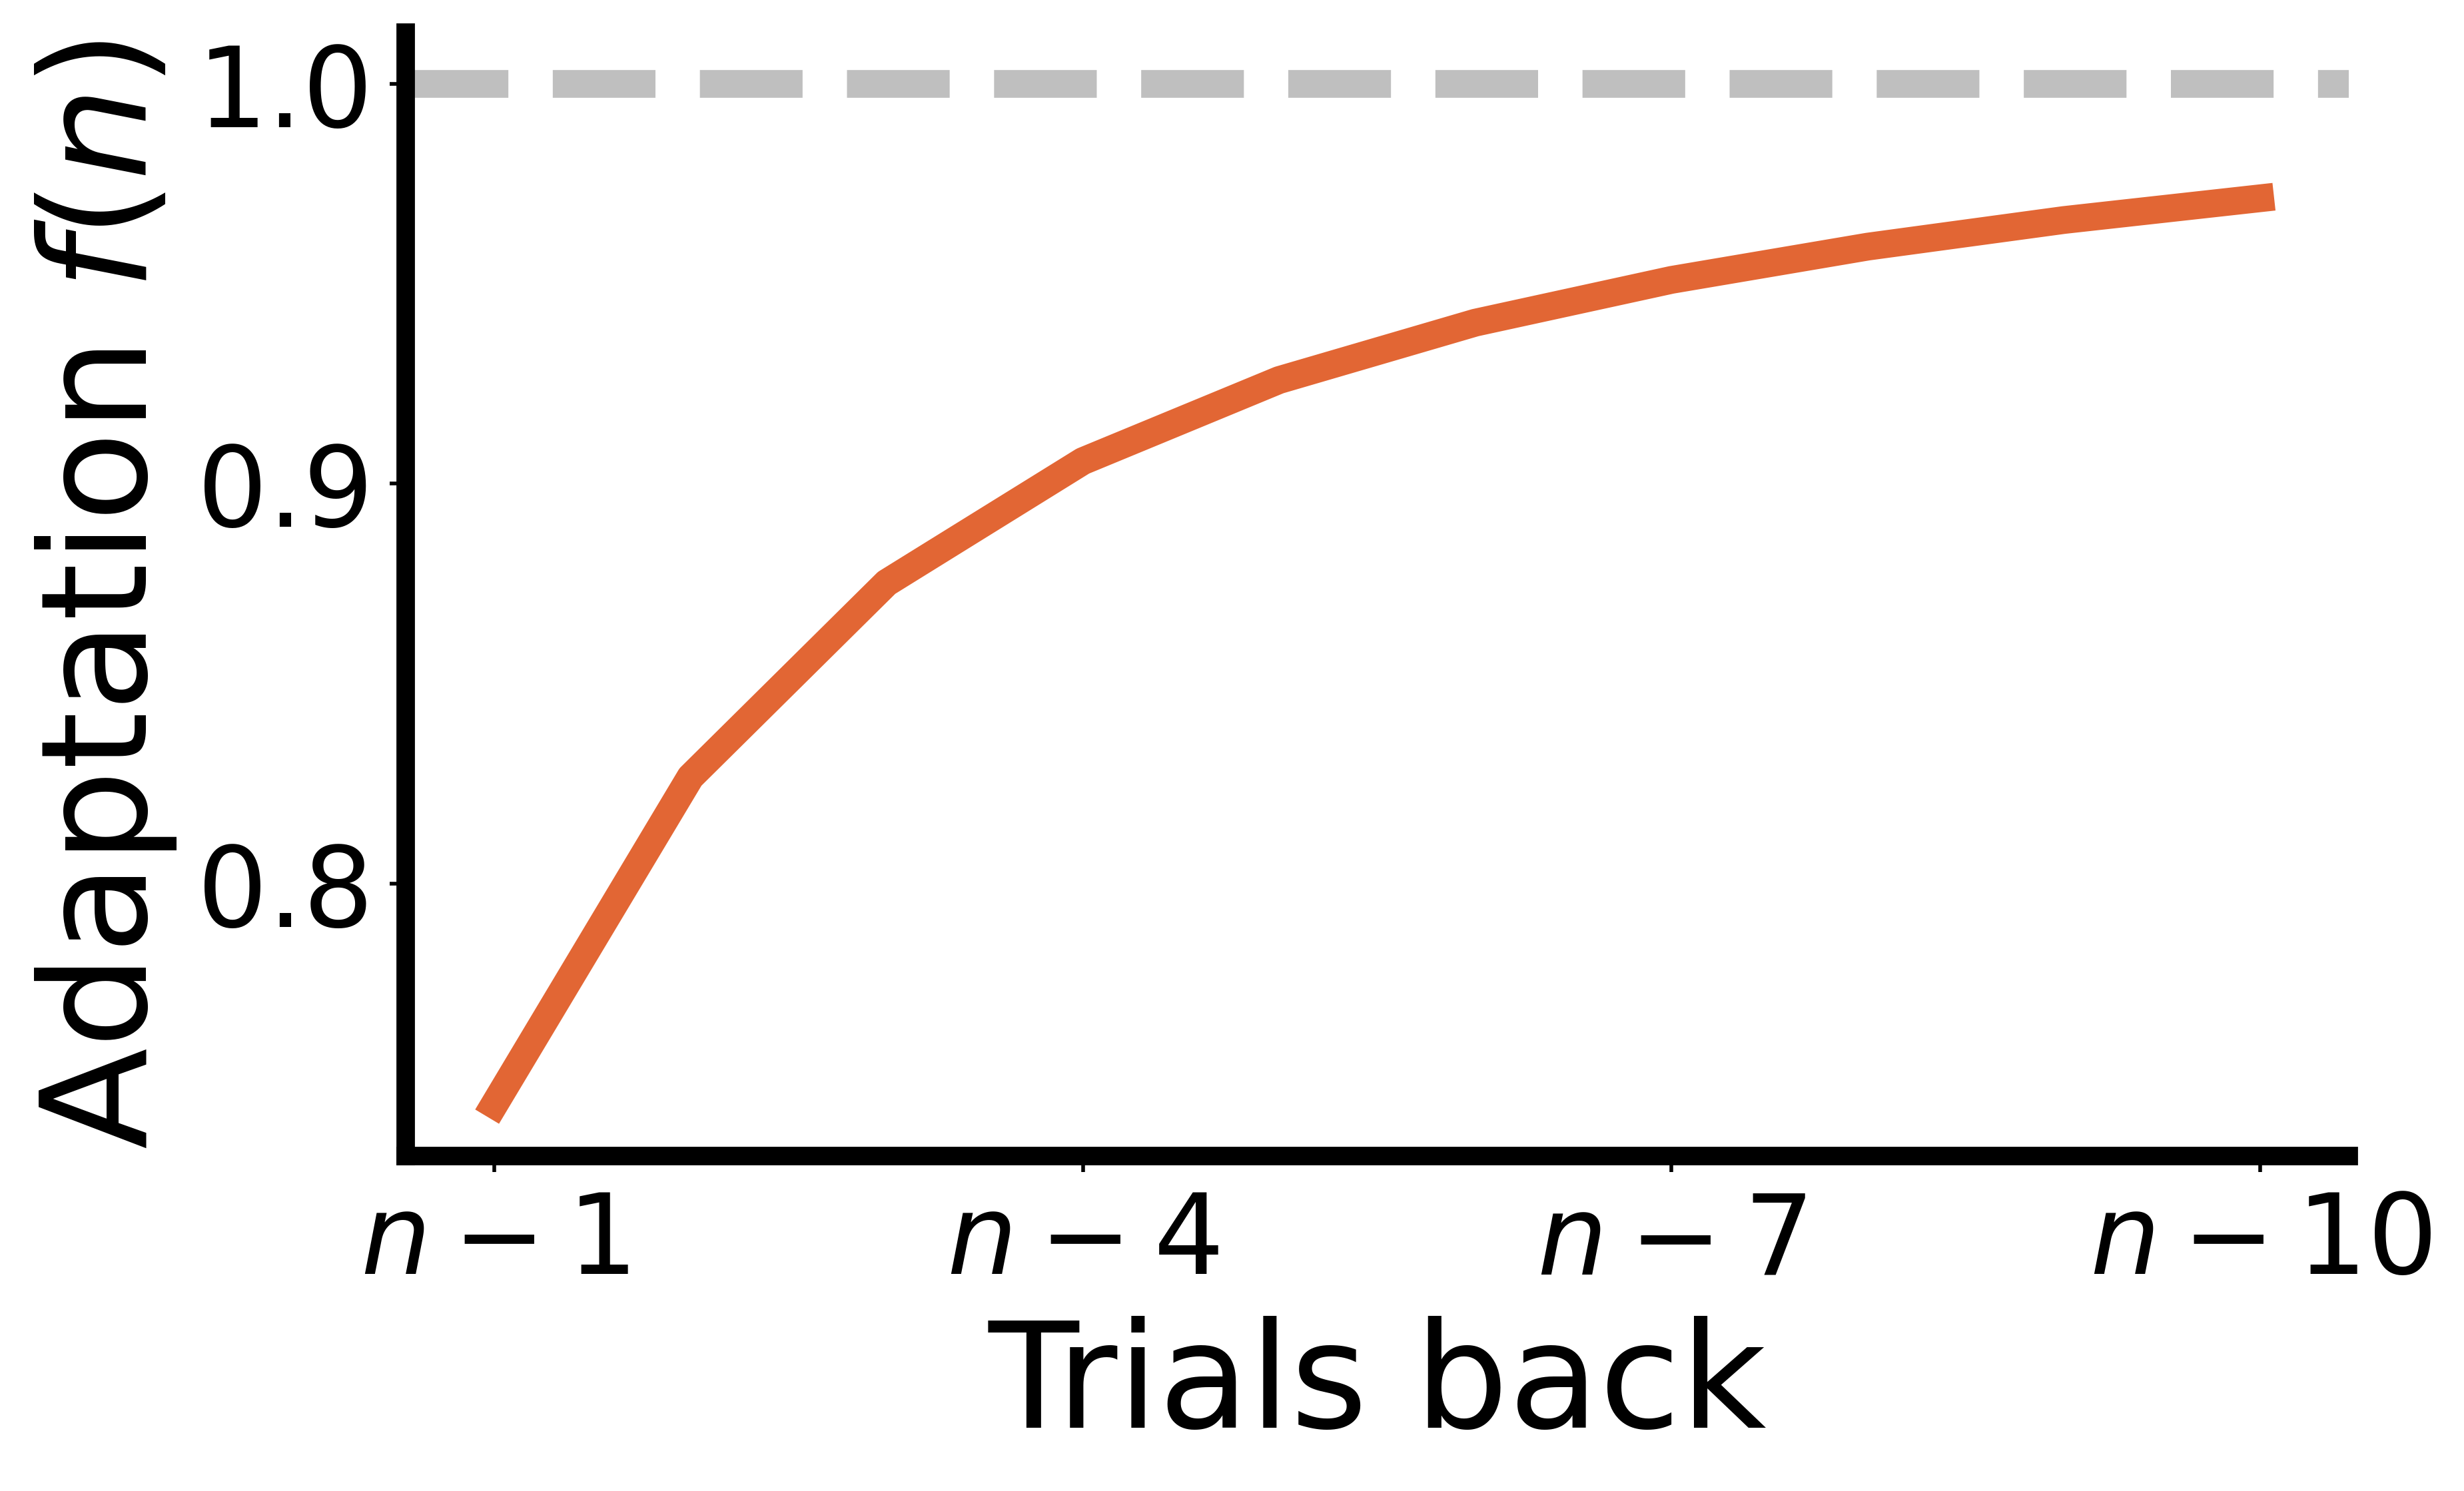

In [146]:
import numpy as np
import matplotlib.pyplot as plt

def adaptation(n_back, a_fast=0.25, tau_fast=1.5, a_slow=0.15, tau_slow=6):
    """Double-exponential adaptation function over trials back."""
    return 1 - a_fast * np.exp(-n_back / tau_fast) - a_slow * np.exp(-n_back / tau_slow)

# Trials back (1 = most recent, increasing = further back)
n_back = np.arange(1, 11)
y = adaptation(n_back)

fig, ax = plt.subplots(figsize=(7.5, 4.58), dpi=500)
ax.plot(n_back, y, color='#E26634', lw=6)
ax.axhline(1, lw=6, alpha=0.5, ls='--', color='gray')

# X-axis: n-1 (left) → n-3, n-5 ... (right)
step = 3
xticks = n_back[::step]
ax.set_xticks(xticks)
ax.set_xticklabels([f'$n-{i}$' for i in xticks], fontsize=24)

# Y-axis: 3 ticks only
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
ax.tick_params(axis='y', labelsize=24)

# Labels
ax.set_xlabel('Trials back', fontsize=32)
ax.set_ylabel('Adaptation $f(n)$', fontsize=32)

# Borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(4)

plt.tight_layout()
fig.savefig("adaptation_fig.pdf", format="pdf")
plt.show()
